Cell 1 — Install / Imports Setup

In [ ]:
# Cell 1 — Install / Imports Setup

# Uncomment this line the first time you run in Colab
# !pip -q install pandas numpy matplotlib scikit-learn fastapi uvicorn httpx openai

import os
import time
import json
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from fastapi import FastAPI
from fastapi.testclient import TestClient

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Cell 2 — Simulate Factory OT Data (PLC / Sensors)

In [ ]:
# Cell 2 — Simulate Factory OT Data (Improved / More Balanced Version)

def generate_plc_data(n=1200):
    rows = []

    for i in range(n):
        machine_id = f"CNC_{np.random.randint(1, 6)}"
        shift = np.random.choice(["A", "B", "C"])

        # Base process behavior
        speed = np.random.normal(1500, 130)
        torque = np.random.normal(39, 7)
        tool_wear = max(0, np.random.normal(135, 70))

        # Derived signals
        temperature = (
            np.random.normal(300, 5)
            + 0.035 * tool_wear
            + 0.12 * max(0, torque - 35)
            + 0.003 * max(0, speed - 1500)
        )

        vibration = (
            np.random.normal(2.3, 0.6)
            + 0.005 * max(0, speed - 1450)
            + 0.003 * max(0, torque - 38)
        )

        energy_kw = (
            np.random.normal(10.2, 1.3)
            + 0.035 * max(0, torque - 35)
            + 0.012 * max(0, speed - 1450)
        )

        # --- Controlled fault injection ---
        fault = "normal"

        # Tool wear fault: slightly easier to trigger than before
        if tool_wear > 185 and temperature > 307 and torque > 41 and np.random.rand() > 0.35:
            fault = "tool_wear"

        # Overheating fault
        if temperature > 310 and torque > 41 and np.random.rand() > 0.45:
            fault = "overheating"

        # Vibration fault
        if vibration > 3.6 and speed > 1575 and np.random.rand() > 0.45:
            fault = "vibration_fault"

        # Combined fault: keep rarer but not too rare
        if tool_wear > 210 and vibration > 3.8 and temperature > 309 and np.random.rand() > 0.55:
            fault = "combined_fault"

        # Small probability of anomaly escalation near thresholds
        near_fault = (
            (tool_wear > 175 and temperature > 305) or
            (vibration > 3.3 and speed > 1550) or
            (temperature > 308 and torque > 40)
        )
        if fault == "normal" and near_fault and np.random.rand() > 0.88:
            fault = np.random.choice(["tool_wear", "overheating", "vibration_fault"])

        failure = 0 if fault == "normal" else 1

        rows.append(
            {
                "timestamp": pd.Timestamp("2026-03-01") + pd.Timedelta(minutes=i),
                "machine_id": machine_id,
                "shift": shift,
                "temperature_k": round(float(temperature), 2),
                "vibration_mm_s": round(float(vibration), 2),
                "spindle_speed_rpm": round(float(speed), 2),
                "torque_nm": round(float(torque), 2),
                "tool_wear_min": round(float(tool_wear), 2),
                "energy_kw": round(float(energy_kw), 2),
                "failure": failure,
                "failure_type": fault,
            }
        )
    return pd.DataFrame(rows)

# Regenerate dataset
plc_df = generate_plc_data()

print("New dataset shape:", plc_df.shape)
print("\nFailure type distribution:")
print(plc_df["failure_type"].value_counts())

print("\nFailure ratio:")
print(plc_df["failure"].value_counts(normalize=True).round(3))

plc_df.head()

New dataset shape: (1200, 11)

Failure type distribution:
failure_type
normal             1010
vibration_fault      74
overheating          65
tool_wear            49
combined_fault        2
Name: count, dtype: int64

Failure ratio:
failure
0    0.842
1    0.158
Name: proportion, dtype: float64


,timestamp,machine_id,shift,temperature_k,vibration_mm_s,spindle_speed_rpm,torque_nm,tool_wear_min,energy_kw,failure,failure_type
0,2026-03-01 00:00:00,CNC_4,B,297.78,2.50,1561.94,38.75,0.00,12.56,0,normal
1,2026-03-01 00:01:00,CNC_4,A,310.65,2.25,1285.23,51.36,209.51,10.77,1,vibration_fault
2,2026-03-01 00:02:00,CNC_1,B,307.11,2.14,1447.97,40.14,84.59,11.75,0,normal
3,2026-03-01 00:03:00,CNC_2,B,296.57,1.98,1648.64,40.29,152.65,12.48,0,normal
4,2026-03-01 00:04:00,CNC_2,B,299.40,4.49,1739.20,45.29,103.97,15.12,1,overheating


Cell 3 — Inspect the Simulated PLC Dataset

In [ ]:
# Cell 3 — Inspect the Simulated PLC Dataset

print("Dataset shape:", plc_df.shape)
print("\nFailure type distribution:")
print(plc_df["failure_type"].value_counts())

print("\nBinary failure distribution:")
print(plc_df["failure"].value_counts())

plc_df.head(10)

Dataset shape: (1200, 11)

Failure type distribution:
failure_type
normal             1010
vibration_fault      74
overheating          65
tool_wear            49
combined_fault        2
Name: count, dtype: int64

Binary failure distribution:
failure
0    1010
1     190
Name: count, dtype: int64


,timestamp,machine_id,shift,temperature_k,vibration_mm_s,spindle_speed_rpm,torque_nm,tool_wear_min,energy_kw,failure,failure_type
0,2026-03-01 00:00:00,CNC_4,B,297.78,2.50,1561.94,38.75,0.00,12.56,0,normal
1,2026-03-01 00:01:00,CNC_4,A,310.65,2.25,1285.23,51.36,209.51,10.77,1,vibration_fault
2,2026-03-01 00:02:00,CNC_1,B,307.11,2.14,1447.97,40.14,84.59,11.75,0,normal
3,2026-03-01 00:03:00,CNC_2,B,296.57,1.98,1648.64,40.29,152.65,12.48,0,normal
4,2026-03-01 00:04:00,CNC_2,B,299.40,4.49,1739.20,45.29,103.97,15.12,1,overheating
5,2026-03-01 00:05:00,CNC_2,B,296.65,3.18,1547.49,49.83,78.84,12.25,0,normal
6,2026-03-01 00:06:00,CNC_3,B,316.62,2.78,1550.05,44.59,213.47,13.29,1,tool_wear
7,2026-03-01 00:07:00,CNC_3,C,308.36,3.43,1628.69,39.32,189.54,16.46,0,normal
8,2026-03-01 00:08:00,CNC_3,C,309.06,3.10,1474.34,36.83,116.46,10.42,0,normal
9,2026-03-01 00:09:00,CNC_4,A,306.73,0.71,1479.19,43.73,139.91,9.37,0,normal


Cell 4 — Visualize OT Signals

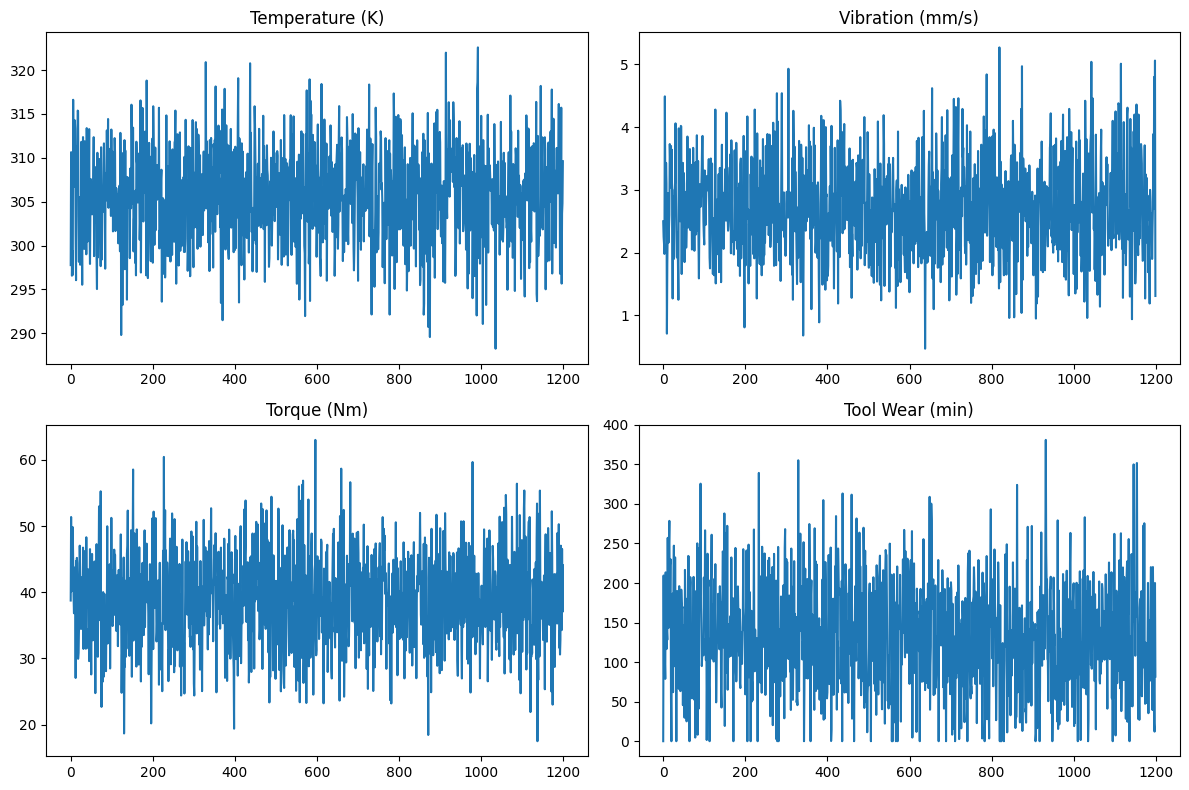

In [ ]:
# Cell 4 — Visualize OT Signals

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plc_df["temperature_k"].plot(ax=axes[0, 0], title="Temperature (K)")
plc_df["vibration_mm_s"].plot(ax=axes[0, 1], title="Vibration (mm/s)")
plc_df["torque_nm"].plot(ax=axes[1, 0], title="Torque (Nm)")
plc_df["tool_wear_min"].plot(ax=axes[1, 1], title="Tool Wear (min)")

plt.tight_layout()
plt.show()

Cell 5 — Simulate OPC-UA Style OT Snapshot

In [ ]:
# Cell 5 — Simulate OPC-UA Style OT Snapshot (Improved Version)

# OPC-UA node mapping for simulated PLC tags
OT_TAG_MAP = {
    "temperature_k": "ns=2;s=CNC.Temperature",
    "vibration_mm_s": "ns=2;s=CNC.Vibration",
    "spindle_speed_rpm": "ns=2;s=CNC.SpindleSpeed",
    "torque_nm": "ns=2;s=CNC.Torque",
    "tool_wear_min": "ns=2;s=CNC.ToolWear",
    "energy_kw": "ns=2;s=CNC.EnergyKW",
    "machine_id": "ns=2;s=CNC.MachineID",
    "timestamp": "ns=2;s=CNC.Timestamp",
}

def plc_row_to_opcua_snapshot(row: pd.Series) -> Dict[str, Any]:
    """
    Convert a PLC dataset row into an OPC-UA-like node snapshot.
    Ensures numpy types are converted to Python native types.
    """

    snapshot = {}

    for column in OT_TAG_MAP.keys():
        value = row[column]

        # Convert numpy numeric types to Python native types
        if isinstance(value, (np.float32, np.float64)):
            value = float(value)

        # Convert numpy integers
        if isinstance(value, (np.int32, np.int64)):
            value = int(value)

        snapshot[OT_TAG_MAP[column]] = value

    return snapshot


# Generate example OPC-UA snapshot
sample_snapshot = plc_row_to_opcua_snapshot(plc_df.iloc[0])

print("Sample OPC-UA snapshot:")
sample_snapshot

Sample OPC-UA snapshot:


{'ns=2;s=CNC.Temperature': 297.78,
 'ns=2;s=CNC.Vibration': 2.5,
 'ns=2;s=CNC.SpindleSpeed': 1561.94,
 'ns=2;s=CNC.Torque': 38.75,
 'ns=2;s=CNC.ToolWear': 0.0,
 'ns=2;s=CNC.EnergyKW': 12.56,
 'ns=2;s=CNC.MachineID': 'CNC_4',
 'ns=2;s=CNC.Timestamp': Timestamp('2026-03-01 00:00:00')}

Cell 6 — Simulated ERP / MES REST API

In [ ]:
# Cell 6 — Simulated ERP / MES REST API

erp_app = FastAPI(title="ERP / MES Simulator")

# Simulated maintenance / MES records
maintenance_records = {
    "CNC_1": {
        "last_maintenance": "2026-02-15",
        "recent_failures": ["tool_wear"],
        "production_order": "PO-1001",
        "maintenance_team": "Team_A"
    },
    "CNC_2": {
        "last_maintenance": "2026-02-10",
        "recent_failures": ["overheating"],
        "production_order": "PO-1002",
        "maintenance_team": "Team_B"
    },
    "CNC_3": {
        "last_maintenance": "2026-02-21",
        "recent_failures": ["vibration_fault"],
        "production_order": "PO-1003",
        "maintenance_team": "Team_A"
    },
    "CNC_4": {
        "last_maintenance": "2026-02-28",
        "recent_failures": ["tool_wear", "overheating"],
        "production_order": "PO-1004",
        "maintenance_team": "Team_C"
    },
    "CNC_5": {
        "last_maintenance": "2026-02-08",
        "recent_failures": [],
        "production_order": "PO-1005",
        "maintenance_team": "Team_B"
    },
}

@erp_app.get("/machine/{machine_id}/context")
def get_machine_context(machine_id: str):
    record = maintenance_records.get(
        machine_id,
        {
            "last_maintenance": "unknown",
            "recent_failures": [],
            "production_order": "unknown",
            "maintenance_team": "unknown"
        }
    )

    return {
        "machine_id": machine_id,
        "maintenance": record,
        "line_supervisor": f"Supervisor_{machine_id[-1]}",
        "current_shift_target": int(np.random.randint(80, 120)),
        "current_shift_progress": int(np.random.randint(20, 80)),
        "mes_status": np.random.choice(["running", "under_observation", "maintenance_due"])
    }

# Create a Colab-friendly local test client
erp_client = TestClient(erp_app)

# Example API call
example_erp_response = erp_client.get("/machine/CNC_3/context").json()

print("Example ERP / MES API response:")
example_erp_response

Example ERP / MES API response:


{'machine_id': 'CNC_3',
 'maintenance': {'last_maintenance': '2026-02-21',
  'recent_failures': ['vibration_fault'],
  'production_order': 'PO-1003',
  'maintenance_team': 'Team_A'},
 'line_supervisor': 'Supervisor_3',
 'current_shift_target': 114,
 'current_shift_progress': 30,
 'mes_status': 'under_observation'}

Cell 7 — Simulated Cloud Knowledge Service

In [ ]:
# Cell 7 — Simulated Cloud Knowledge Service

cloud_app = FastAPI(title="Cloud Knowledge Service")

# Simulated cloud failure case database
failure_case_db = [
    {
        "case_id": "FC-001",
        "pattern": {
            "temperature_k": 309,
            "torque_nm": 45,
            "tool_wear_min": 210
        },
        "failure_type": "tool_wear",
        "recommended_action": "Inspect cutting tool and replace if wear exceeds threshold."
    },
    {
        "case_id": "FC-002",
        "pattern": {
            "temperature_k": 313,
            "torque_nm": 44,
            "tool_wear_min": 150
        },
        "failure_type": "overheating",
        "recommended_action": "Inspect cooling flow and reduce spindle load temporarily."
    },
    {
        "case_id": "FC-003",
        "pattern": {
            "vibration_mm_s": 4.5,
            "spindle_speed_rpm": 1650
        },
        "failure_type": "vibration_fault",
        "recommended_action": "Inspect spindle alignment and bearing condition."
    },
    {
        "case_id": "FC-004",
        "pattern": {
            "temperature_k": 312,
            "vibration_mm_s": 4.2,
            "tool_wear_min": 225
        },
        "failure_type": "combined_fault",
        "recommended_action": "Stop after current cycle and inspect both tool wear and spindle assembly."
    },
]

@cloud_app.post("/failure_cases/search")
def search_failure_cases(payload: Dict[str, Any]):
    temp = payload.get("temperature_k", 0)
    torque = payload.get("torque_nm", 0)
    wear = payload.get("tool_wear_min", 0)
    vibration = payload.get("vibration_mm_s", 0)
    speed = payload.get("spindle_speed_rpm", 0)

    matches = []

    for case in failure_case_db:
        score = 0
        pattern = case["pattern"]

        if "temperature_k" in pattern and abs(temp - pattern["temperature_k"]) < 5:
            score += 1
        if "torque_nm" in pattern and abs(torque - pattern["torque_nm"]) < 5:
            score += 1
        if "tool_wear_min" in pattern and abs(wear - pattern["tool_wear_min"]) < 40:
            score += 1
        if "vibration_mm_s" in pattern and abs(vibration - pattern["vibration_mm_s"]) < 1.0:
            score += 1
        if "spindle_speed_rpm" in pattern and abs(speed - pattern["spindle_speed_rpm"]) < 120:
            score += 1

        # Keep only sufficiently similar cases
        if score >= 2 or (score >= 1 and case["failure_type"] == "vibration_fault"):
            matches.append({
                **case,
                "match_score": score
            })

    matches = sorted(matches, key=lambda x: x["match_score"], reverse=True)

    return {
        "matches": matches,
        "num_matches": len(matches)
    }

@cloud_app.get("/benchmarks/{machine_id}")
def get_benchmarks(machine_id: str):
    return {
        "machine_id": machine_id,
        "avg_temperature_k": 301.5,
        "avg_vibration_mm_s": 2.4,
        "avg_torque_nm": 38.0,
        "avg_tool_wear_min": 120.0,
        "note": "Machine operating above benchmark thresholds should be inspected."
    }

# Colab-friendly client
cloud_client = TestClient(cloud_app)

# Example cloud query using one PLC sample row
cloud_test_payload = plc_df.iloc[25][[
    "temperature_k",
    "torque_nm",
    "tool_wear_min",
    "vibration_mm_s",
    "spindle_speed_rpm"
]].to_dict()

cloud_search_result = cloud_client.post("/failure_cases/search", json=cloud_test_payload).json()
cloud_benchmark_result = cloud_client.get("/benchmarks/CNC_4").json()

print("Example cloud failure search result:")
print(json.dumps(cloud_search_result, indent=2))

print("\nExample benchmark result:")
print(json.dumps(cloud_benchmark_result, indent=2))

Example cloud failure search result:
{
  "matches": [
    {
      "case_id": "FC-003",
      "pattern": {
        "vibration_mm_s": 4.5,
        "spindle_speed_rpm": 1650
      },
      "failure_type": "vibration_fault",
      "recommended_action": "Inspect spindle alignment and bearing condition.",
      "match_score": 1
    }
  ],
  "num_matches": 1
}

Example benchmark result:
{
  "machine_id": "CNC_4",
  "avg_temperature_k": 301.5,
  "avg_vibration_mm_s": 2.4,
  "avg_torque_nm": 38.0,
  "avg_tool_wear_min": 120.0,
  "note": "Machine operating above benchmark thresholds should be inspected."
}


Cell 8 — Policy Engine

In [ ]:
# Cell 8 — Policy Engine

@dataclass
class PolicyConfig:
    enable_cloud: bool = True
    min_anomaly_probability: float = 0.60
    redact_fields: Optional[List[str]] = None


# Default policy configuration
policy = PolicyConfig(
    enable_cloud=True,
    min_anomaly_probability=0.60,
    redact_fields=["timestamp"]
)

def evaluate_cloud_policy(event_payload: Dict[str, Any],
                          anomaly_probability: float,
                          policy: PolicyConfig) -> Dict[str, Any]:
    """
    Evaluate whether cloud interaction is authorized.
    Also sanitize payload by removing redacted fields.
    """
    if not policy.enable_cloud:
        return {
            "authorized": False,
            "reason": "Cloud interaction disabled by policy."
        }

    if anomaly_probability < policy.min_anomaly_probability:
        return {
            "authorized": False,
            "reason": f"Anomaly probability {anomaly_probability:.2f} below policy threshold."
        }

    sanitized_payload = dict(event_payload)

    for field in (policy.redact_fields or []):
        sanitized_payload.pop(field, None)

    return {
        "authorized": True,
        "reason": "Authorized by policy.",
        "payload": sanitized_payload
    }


# Example test with one PLC row
test_event = plc_df.iloc[10].to_dict()
test_anomaly_probability = 0.72

policy_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=test_anomaly_probability,
    policy=policy
)

print("Policy evaluation result:")
print(json.dumps(policy_result, indent=2, default=str))

Policy evaluation result:
{
  "authorized": true,
  "reason": "Authorized by policy.",
  "payload": {
    "machine_id": "CNC_2",
    "shift": "A",
    "temperature_k": 314.28,
    "vibration_mm_s": 1.82,
    "spindle_speed_rpm": 1383.15,
    "torque_nm": 38.47,
    "tool_wear_min": 128.2,
    "energy_kw": 10.11,
    "failure": 0,
    "failure_type": "normal"
  }
}


In [ ]:
# Optional extra test for Cell 8

test_event = plc_df.iloc[10].to_dict()

low_score_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=0.20,
    policy=policy
)

high_score_result = evaluate_cloud_policy(
    event_payload=test_event,
    anomaly_probability=0.85,
    policy=policy
)

print("Low anomaly score result:")
print(json.dumps(low_score_result, indent=2, default=str))

print("\nHigh anomaly score result:")
print(json.dumps(high_score_result, indent=2, default=str))

Low anomaly score result:
{
  "authorized": false,
  "reason": "Anomaly probability 0.20 below policy threshold."
}

High anomaly score result:
{
  "authorized": true,
  "reason": "Authorized by policy.",
  "payload": {
    "machine_id": "CNC_2",
    "shift": "A",
    "temperature_k": 314.28,
    "vibration_mm_s": 1.82,
    "spindle_speed_rpm": 1383.15,
    "torque_nm": 38.47,
    "tool_wear_min": 128.2,
    "energy_kw": 10.11,
    "failure": 0,
    "failure_type": "normal"
  }
}


Cell 9 — Edge Intelligence (Sense → Diagnose)

In [ ]:
# Cell 9 — Edge Intelligence (Sense → Diagnose)

# Features used by the edge model
features = [
    "temperature_k",
    "vibration_mm_s",
    "spindle_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "energy_kw"
]

X = plc_df[features]
y = plc_df["failure"]

# Train / test split
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, plc_df, test_size=0.25, random_state=42, stratify=y
)

# DDAK-Sense model
sense_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

sense_model.fit(X_train, y_train)

# Evaluate edge detection performance
pred = sense_model.predict(X_test)
proba = sense_model.predict_proba(X_test)[:, 1]

print("Edge Sense Accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, pred))


# DDAK-Diagnose: lightweight root-cause logic
def diagnose_root_cause(row: Dict[str, Any]) -> str:
    temp = row["temperature_k"]
    vib = row["vibration_mm_s"]
    speed = row["spindle_speed_rpm"]
    torque = row["torque_nm"]
    wear = row["tool_wear_min"]

    # Priority: combined fault first
    if wear > 220 and vib > 4.0 and temp > 311:
        return "combined_fault"
    if wear > 210 and temp > 308 and torque > 43:
        return "tool_wear"
    if temp > 312 and torque > 42:
        return "overheating"
    if vib > 4.0 and speed > 1600:
        return "vibration_fault"

    return "uncertain"


# Example diagnosis on one test row
test_row = df_test.iloc[0].to_dict()
example_diagnosis = diagnose_root_cause(test_row)

print("Example test row failure type:", test_row["failure_type"])
print("Diagnosed root cause:", example_diagnosis)

Edge Sense Accuracy: 0.87

Classification report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       253
           1       0.60      0.51      0.55        47

    accuracy                           0.87       300
   macro avg       0.76      0.72      0.74       300
weighted avg       0.86      0.87      0.87       300

Example test row failure type: normal
Diagnosed root cause: uncertain


In [ ]:
print("Training failure distribution:")
print(y_train.value_counts())

print("\nTest failure distribution:")
print(y_test.value_counts())

Training failure distribution:
failure
0    757
1    143
Name: count, dtype: int64

Test failure distribution:
failure
0    253
1     47
Name: count, dtype: int64


In [ ]:
# Set your OpenAI API key

import os

os.environ["OPENAI_API_KEY"] = "XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX" #Insert your API key here

print("OpenAI API key loaded.")

OpenAI API key loaded.


📦 Cell 10 — LLM Reasoning Module

In [ ]:
# Cell 10 — LLM Reasoning

USE_OPENAI = bool(os.getenv("OPENAI_API_KEY"))

def build_llm_prompt(local_context, diagnosis, erp_context, cloud_context):

    prompt = f"""
You are an industrial AI assistant inside the DDAK-Connect system.

Machine telemetry:
Temperature: {local_context['temperature_k']} K
Vibration: {local_context['vibration_mm_s']} mm/s
Speed: {local_context['spindle_speed_rpm']} rpm
Torque: {local_context['torque_nm']} Nm
Tool wear: {local_context['tool_wear_min']} min

Edge diagnosis:
{diagnosis}

ERP context:
{erp_context}

Cloud knowledge matches:
{cloud_context}

Your task:
1. Explain the most likely issue
2. Provide a clear cause
3. Recommend an operator action

Respond concisely.
"""

    return prompt


def fallback_llm_response(diagnosis):

    if diagnosis == "tool_wear":
        return "The machine shows symptoms consistent with excessive tool wear. The cutting tool should be inspected and replaced if wear limits are exceeded."

    if diagnosis == "overheating":
        return "The machine temperature is above normal operating levels. Cooling systems and spindle load should be inspected."

    if diagnosis == "vibration_fault":
        return "Elevated vibration levels indicate possible spindle or bearing issues. Mechanical inspection is recommended."

    if diagnosis == "combined_fault":
        return "Multiple abnormal signals suggest a combined mechanical fault involving tool wear and spindle instability."

    return "No clear fault pattern detected. Continue monitoring machine operation."


def run_llm_reasoning(local_context, diagnosis, erp_context, cloud_context):

    if not USE_OPENAI:
        return fallback_llm_response(diagnosis)

    from openai import OpenAI
    client = OpenAI()

    prompt = build_llm_prompt(local_context, diagnosis, erp_context, cloud_context)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are an industrial diagnostic assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2
    )

    return response.choices[0].message.content

Cell 11 — End-to-End DDAK-Connect Orchestration

In [ ]:
# Cell 11 — End-to-End DDAK-Connect Orchestration

def run_ddak_connect_case(row: pd.Series, policy: PolicyConfig):
    timings = {}

    # -----------------------------
    # 1. OT ingestion
    # -----------------------------
    t0 = time.time()
    opcua_snapshot = plc_row_to_opcua_snapshot(row)
    timings["ot_ingestion_ms"] = (time.time() - t0) * 1000

    # -----------------------------
    # 2. IT ingestion
    # -----------------------------
    t1 = time.time()
    erp_context = erp_client.get(f"/machine/{row['machine_id']}/context").json()
    timings["it_ingestion_ms"] = (time.time() - t1) * 1000

    # -----------------------------
    # 3. Edge intelligence (Sense)
    # -----------------------------
    t2 = time.time()
    local_features = row[features].values.reshape(1, -1)
    anomaly_probability = float(sense_model.predict_proba(local_features)[:, 1][0])
    local_prediction = int(sense_model.predict(local_features)[0])
    diagnosis = diagnose_root_cause(row.to_dict())
    timings["edge_analysis_ms"] = (time.time() - t2) * 1000

    # -----------------------------
    # 4. Policy-governed cloud interaction
    # -----------------------------
    t3 = time.time()
    policy_result = evaluate_cloud_policy(
        event_payload=row.to_dict(),
        anomaly_probability=anomaly_probability,
        policy=policy
    )

    cloud_context = {"matches": [], "benchmarks": {}}

    if policy_result["authorized"]:
        cloud_context = cloud_client.post(
            "/failure_cases/search",
            json=policy_result["payload"]
        ).json()

        cloud_context["benchmarks"] = cloud_client.get(
            f"/benchmarks/{row['machine_id']}"
        ).json()

    timings["cloud_interaction_ms"] = (time.time() - t3) * 1000

    # -----------------------------
    # 5. LLM reasoning
    # -----------------------------
    t4 = time.time()
    llm_explanation = run_llm_reasoning(
        local_context=row.to_dict(),
        diagnosis=diagnosis,
        erp_context=erp_context,
        cloud_context=cloud_context
    )
    timings["llm_reasoning_ms"] = (time.time() - t4) * 1000

    # -----------------------------
    # 6. Final operator result
    # -----------------------------
    result = {
        "machine_id": row["machine_id"],
        "timestamp": str(row["timestamp"]),
        "actual_failure": int(row["failure"]),
        "actual_failure_type": row["failure_type"],
        "predicted_failure": local_prediction,
        "anomaly_probability": round(anomaly_probability, 4),
        "diagnosis": diagnosis,
        "cloud_used": policy_result["authorized"],
        "policy_reason": policy_result["reason"],
        "opcua_snapshot": opcua_snapshot,
        "erp_context": erp_context,
        "cloud_context": cloud_context,
        "llm_explanation": llm_explanation,
        "timings_ms": {k: round(v, 2) for k, v in timings.items()},
        "total_latency_ms": round(sum(timings.values()), 2)
    }

    return result

Cell 12 — Run One Full DDAK-Connect Example

In [ ]:
# Cell 12 — Run One Full DDAK-Connect Example

# Use a test row — you can change the index to inspect different cases
example_row = df_test.iloc[10]

example_result = run_ddak_connect_case(example_row, policy)

print("=" * 100)
print("DDAK-Connect Full Case Result")
print("=" * 100)

print("\nMachine ID:", example_result["machine_id"])
print("Timestamp:", example_result["timestamp"])
print("Actual failure label:", example_result["actual_failure"])
print("Actual failure type:", example_result["actual_failure_type"])
print("Predicted failure:", example_result["predicted_failure"])
print("Anomaly probability:", example_result["anomaly_probability"])
print("Diagnosis:", example_result["diagnosis"])
print("Cloud used:", example_result["cloud_used"])
print("Policy reason:", example_result["policy_reason"])

print("\nERP / MES Context:")
print(json.dumps(example_result["erp_context"], indent=2))

print("\nCloud Context:")
print(json.dumps(example_result["cloud_context"], indent=2))

print("\nLLM Explanation:")
print(example_result["llm_explanation"])

print("\nTimings (ms):")
print(json.dumps(example_result["timings_ms"], indent=2))

print("\nTotal latency (ms):", example_result["total_latency_ms"])

DDAK-Connect Full Case Result

Machine ID: CNC_5
Timestamp: 2026-03-01 07:12:00
Actual failure label: 0
Actual failure type: normal
Predicted failure: 1
Anomaly probability: 0.7408
Diagnosis: vibration_fault
Cloud used: True
Policy reason: Authorized by policy.

ERP / MES Context:
{
  "machine_id": "CNC_5",
  "maintenance": {
    "last_maintenance": "2026-02-08",
    "recent_failures": [],
    "production_order": "PO-1005",
    "maintenance_team": "Team_B"
  },
  "line_supervisor": "Supervisor_5",
  "current_shift_target": 99,
  "current_shift_progress": 49,
  "mes_status": "running"
}

Cloud Context:
{
  "matches": [
    {
      "case_id": "FC-003",
      "pattern": {
        "vibration_mm_s": 4.5,
        "spindle_speed_rpm": 1650
      },
      "failure_type": "vibration_fault",
      "recommended_action": "Inspect spindle alignment and bearing condition.",
      "match_score": 2
    }
  ],
  "num_matches": 1,
  "benchmarks": {
    "machine_id": "CNC_5",
    "avg_temperature_k": 301

Cell 13 — Batch Evaluation (Edge Only vs Hybrid)

In [ ]:
# Cell 13 — Batch Evaluation (Edge Only vs Hybrid)

def diagnosis_success(actual: str, predicted: str) -> int:
    """
    Simple diagnostic match scoring.
    """
    if actual == "normal" and predicted in ["uncertain", "normal"]:
        return 1
    if actual == predicted:
        return 1
    return 0


def compute_augmented_diagnosis_score(row):
    """
    Gives a small quality boost when cloud knowledge retrieves
    a matching historical case.
    """
    base = 1.0 if diagnosis_success(row["actual_failure_type"], row["diagnosis"]) else 0.0
    boost = 0.0

    matches = row.get("cloud_context", {}).get("matches", [])
    if row["cloud_used"] and matches:
        top_case = matches[0]["failure_type"]
        if top_case == row["actual_failure_type"]:
            boost = 0.2

    return min(base + boost, 1.0)


def evaluate_pipeline(df_eval: pd.DataFrame, enable_cloud: bool, n_cases: int = 80):
    local_policy = PolicyConfig(
        enable_cloud=enable_cloud,
        min_anomaly_probability=0.60,
        redact_fields=["timestamp"]
    )

    results = []
    sampled = df_eval.sample(min(n_cases, len(df_eval)), random_state=42)

    for _, row in sampled.iterrows():
        result = run_ddak_connect_case(row, local_policy)
        results.append(result)

    results_df = pd.DataFrame(results)

    # diagnosis quality
    results_df["diagnosis_match"] = [
        diagnosis_success(a, p)
        for a, p in zip(results_df["actual_failure_type"], results_df["diagnosis"])
    ]

    results_df["augmented_diagnosis_score"] = results_df.apply(
        compute_augmented_diagnosis_score, axis=1
    )

    return results_df


# Run both modes
results_edge_only = evaluate_pipeline(df_test, enable_cloud=False, n_cases=80)
results_hybrid = evaluate_pipeline(df_test, enable_cloud=True, n_cases=80)

print("Edge-only results shape:", results_edge_only.shape)
print("Hybrid results shape:", results_hybrid.shape)

Edge-only results shape: (80, 17)
Hybrid results shape: (80, 17)


Cell 14 — Results Summary Table

In [ ]:
# Cell 14 — Results Summary Table

summary = pd.DataFrame({
    "Mode": ["Edge Only", "Hybrid Edge + Cloud"],
    "Cloud Usage Rate": [
        round(results_edge_only["cloud_used"].mean(), 3),
        round(results_hybrid["cloud_used"].mean(), 3),
    ],
    "Mean Latency (ms)": [
        round(results_edge_only["total_latency_ms"].mean(), 2),
        round(results_hybrid["total_latency_ms"].mean(), 2),
    ],
    "Failure Detection Accuracy": [
        round((results_edge_only["actual_failure"] == results_edge_only["predicted_failure"]).mean(), 3),
        round((results_hybrid["actual_failure"] == results_hybrid["predicted_failure"]).mean(), 3),
    ],
    "Diagnosis Match Rate": [
        round(results_edge_only["diagnosis_match"].mean(), 3),
        round(results_hybrid["diagnosis_match"].mean(), 3),
    ],
    "Diagnostic Quality Score": [
        round(results_edge_only["augmented_diagnosis_score"].mean(), 3),
        round(results_hybrid["augmented_diagnosis_score"].mean(), 3),
    ]
})

print("DDAK-Connect Evaluation Summary")
summary

DDAK-Connect Evaluation Summary


,Mode,Cloud Usage Rate,Mean Latency (ms),Failure Detection Accuracy,Diagnosis Match Rate,Diagnostic Quality Score
0,Edge Only,0.000,2679.20,0.875,0.825,0.825
1,Hybrid Edge + Cloud,0.162,2428.47,0.875,0.825,0.832


Cell 15 — Visual Comparison

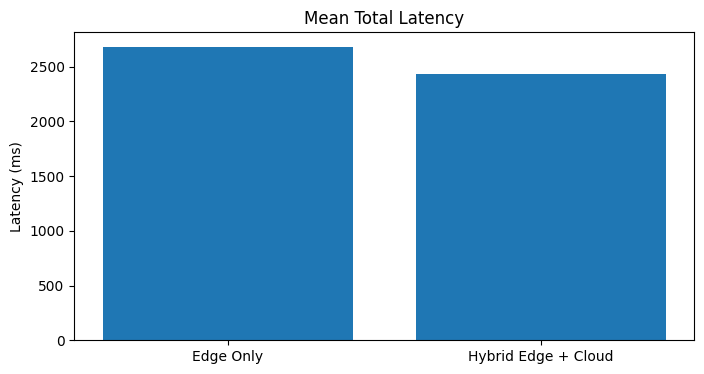

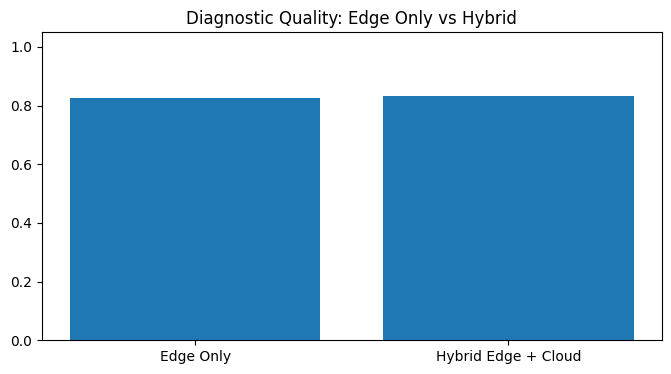

In [ ]:
# Cell 15 — Visual Comparison

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary["Mode"], summary["Mean Latency (ms)"])
ax.set_title("Mean Total Latency")
ax.set_ylabel("Latency (ms)")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary["Mode"], summary["Diagnostic Quality Score"])
ax.set_title("Diagnostic Quality: Edge Only vs Hybrid")
ax.set_ylim(0, 1.05)
plt.show()

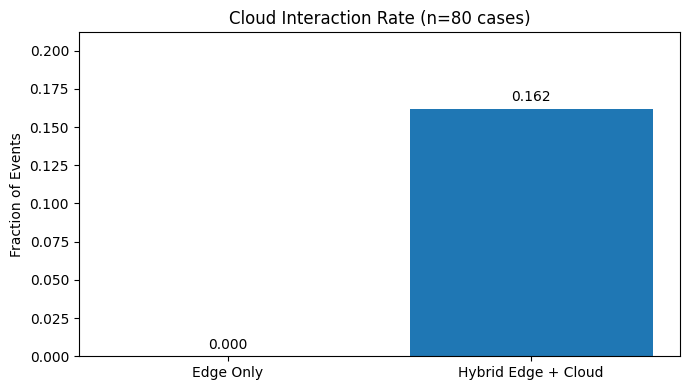

In [ ]:
# Updated Plot 1 — Cloud Interaction Rate

plt.figure(figsize=(7, 4))

labels = ["Edge Only", "Hybrid Edge + Cloud"]
cloud_usage = [0, summary.loc[1, "Cloud Usage Rate"]]

plt.bar(labels, cloud_usage)
plt.title("Cloud Interaction Rate (n=80 cases)")
plt.ylabel("Fraction of Events")
plt.ylim(0, max(cloud_usage) + 0.05)

for i, v in enumerate(cloud_usage):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

Updated Plot 2 — Diagnostic Quality

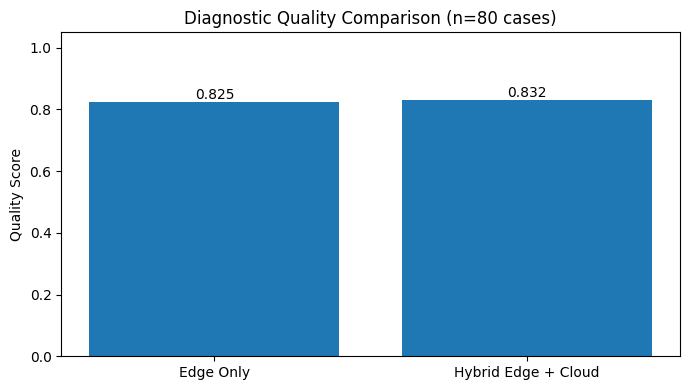

In [ ]:
# Updated Plot 2 — Diagnostic Quality Comparison

plt.figure(figsize=(7, 4))

labels = summary["Mode"]
values = summary["Diagnostic Quality Score"]

plt.bar(labels, values)
plt.title("Diagnostic Quality Comparison (n=80 cases)")
plt.ylabel("Quality Score")
plt.ylim(0, 1.05)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

Updated Plot 3 — Average End-to-End Processing Latency

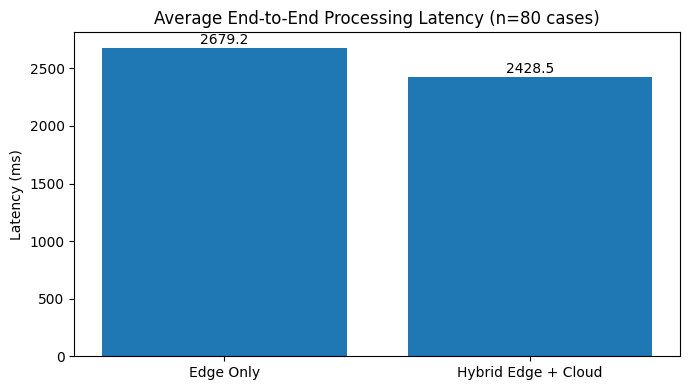

In [ ]:
# Updated Plot 3 — Average End-to-End Processing Latency

plt.figure(figsize=(7, 4))

labels = summary["Mode"]
values = summary["Mean Latency (ms)"]

plt.bar(labels, values)
plt.title("Average End-to-End Processing Latency (n=80 cases)")
plt.ylabel("Latency (ms)")

for i, v in enumerate(values):
    plt.text(i, v + 30, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

New Plot 4 — Latency Breakdown by Pipeline Stage

In [ ]:
# Flatten nested timing dictionaries into top-level columns

def flatten_timing_columns(results_df: pd.DataFrame) -> pd.DataFrame:
    timing_df = results_df["timings_ms"].apply(pd.Series)
    return pd.concat([results_df.drop(columns=["timings_ms"]), timing_df], axis=1)

results_edge_only_flat = flatten_timing_columns(results_edge_only)
results_hybrid_flat = flatten_timing_columns(results_hybrid)

print("Flattened edge-only columns:")
print(results_edge_only_flat.columns.tolist())

print("\nFlattened hybrid columns:")
print(results_hybrid_flat.columns.tolist())

Flattened edge-only columns:
['machine_id', 'timestamp', 'actual_failure', 'actual_failure_type', 'predicted_failure', 'anomaly_probability', 'diagnosis', 'cloud_used', 'policy_reason', 'opcua_snapshot', 'erp_context', 'cloud_context', 'llm_explanation', 'total_latency_ms', 'diagnosis_match', 'augmented_diagnosis_score', 'ot_ingestion_ms', 'it_ingestion_ms', 'edge_analysis_ms', 'cloud_interaction_ms', 'llm_reasoning_ms']

Flattened hybrid columns:
['machine_id', 'timestamp', 'actual_failure', 'actual_failure_type', 'predicted_failure', 'anomaly_probability', 'diagnosis', 'cloud_used', 'policy_reason', 'opcua_snapshot', 'erp_context', 'cloud_context', 'llm_explanation', 'total_latency_ms', 'diagnosis_match', 'augmented_diagnosis_score', 'ot_ingestion_ms', 'it_ingestion_ms', 'edge_analysis_ms', 'cloud_interaction_ms', 'llm_reasoning_ms']


In [ ]:
# New Plot 4 — Latency Breakdown by Pipeline Stage

latency_components = [
    "ot_ingestion_ms",
    "it_ingestion_ms",
    "edge_analysis_ms",
    "cloud_interaction_ms",
    "llm_reasoning_ms"
]

edge_only_latency = [
    results_edge_only_flat[c].mean() for c in latency_components
]

hybrid_latency = [
    results_hybrid_flat[c].mean() for c in latency_components
]

latency_breakdown_df = pd.DataFrame({
    "Component": [
        "OT Ingestion",
        "IT Ingestion",
        "Edge Analysis",
        "Cloud Interaction",
        "LLM Reasoning"
    ],
    "Edge Only": edge_only_latency,
    "Hybrid Edge + Cloud": hybrid_latency
})

latency_breakdown_df

,Component,Edge Only,Hybrid Edge + Cloud
0,OT Ingestion,0.051500,0.049125
1,IT Ingestion,10.941250,7.342250
2,Edge Analysis,25.278250,21.562875
3,Cloud Interaction,0.024125,1.745250
4,LLM Reasoning,2642.903500,2397.772375


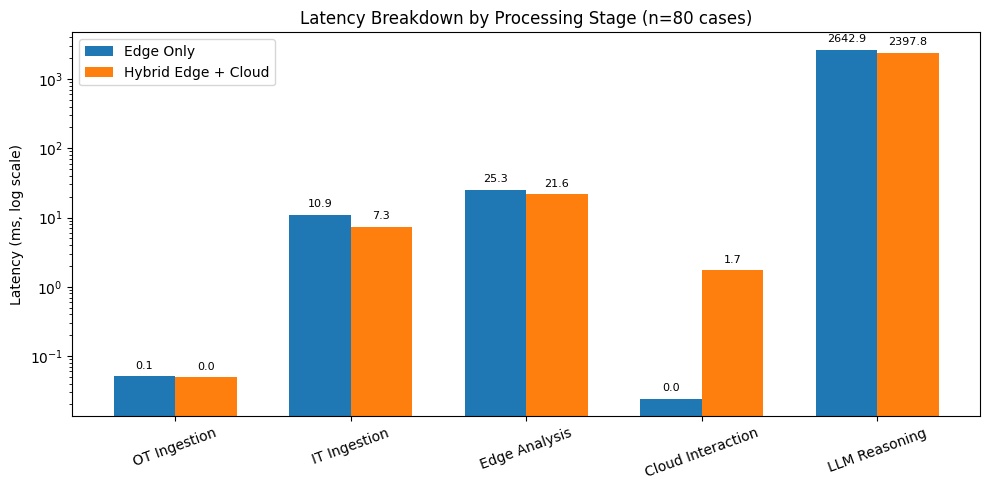

In [ ]:
# Final Improved Plot — Latency Breakdown by Processing Stage

x = np.arange(len(latency_breakdown_df["Component"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, latency_breakdown_df["Edge Only"], width, label="Edge Only")
bars2 = plt.bar(x + width/2, latency_breakdown_df["Hybrid Edge + Cloud"], width, label="Hybrid Edge + Cloud")

plt.xticks(x, latency_breakdown_df["Component"], rotation=20)
plt.ylabel("Latency (ms, log scale)")
plt.title("Latency Breakdown by Processing Stage (n=80 cases)")
plt.yscale("log")

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height * 1.2,
                 f"{height:.1f}",
                 ha='center',
                 va='bottom',
                 fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

Cell 16 — Show a Few Hybrid Cases

In [ ]:
# Cell 16 — Show Example Hybrid Cases

sample_cases = results_hybrid.sort_values(
    ["actual_failure", "anomaly_probability"],
    ascending=[False, False]
).head(3)

for idx, row in sample_cases.iterrows():
    print("=" * 100)
    print("Machine:", row["machine_id"])
    print("Actual failure type:", row["actual_failure_type"])
    print("Diagnosis:", row["diagnosis"])
    print("Cloud used:", row["cloud_used"])
    print("Latency (ms):", row["total_latency_ms"])
    print("LLM Explanation:")
    print(row["llm_explanation"])
    print()

Machine: CNC_5
Actual failure type: vibration_fault
Diagnosis: uncertain
Cloud used: True
Latency (ms): 3140.38
LLM Explanation:
1. **Most Likely Issue**: The machine is experiencing potential tool wear and vibration faults, as indicated by the telemetry data and cloud knowledge matches.

2. **Clear Cause**: The tool wear is at 61.34 minutes, which is significantly below the threshold of 210 minutes identified in the failure cases. However, the vibration level of 3.92 mm/s is above the average benchmark of 2.4 mm/s, suggesting possible spindle misalignment or bearing issues.

3. **Recommended Operator Action**: Inspect the cutting tool for wear and replace it if necessary. Additionally, check the spindle alignment and bearing condition to address the elevated vibration levels.

Machine: CNC_4
Actual failure type: vibration_fault
Diagnosis: uncertain
Cloud used: True
Latency (ms): 2730.92
LLM Explanation:
1. **Most Likely Issue**: The machine is experiencing tool wear, which is indicate

In [ ]:
summary.to_csv("ddak_connect_summary.csv", index=False)
results_hybrid.to_csv("ddak_connect_hybrid_results.csv", index=False)
results_edge_only.to_csv("ddak_connect_edge_results.csv", index=False)